In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../inputs/dataset_v2_fs_top60.csv")
df = df.sort_values("fecha")

In [3]:
df["fecha"].describe()

count            644
unique           644
top       2025-08-28
freq               1
Name: fecha, dtype: object

## Pre-procesamiento

In [4]:
df = df.rename(columns={
    "merval_apertura_+1": "merval",
})

In [5]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [6]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [7]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval_cierre_ma_3,0,0.0
emae_tendencia_ciclo_ma_5,0,0.0
merval_apertura,0,0.0
emae_desestacionalizado_lag2,0,0.0
...,...,...
m2_pct10,0,0.0
emae_tendencia_ciclo_diff3,0,0.0
tc_mayorista_pct10,0,0.0
m2_spec_centroid,0,0.0


In [8]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [9]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha

## Train-Test Split

In [10]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(515, 60)
(129, 60)


## Cross-Validation

In [11]:
# Con 515 días de entrenamiento, podemos usar más pliegues y validaciones más largas
# - n_splits=5: cinco validaciones para una estimación más robusta
# - test_size=20: ~1 mes de validación por fold
# - gap=5: separación temporal entre train y test para evitar fuga de información

max_lag = 5

test_size = 20
tscv = TimeSeriesSplit(n_splits=5, test_size=test_size, gap=max_lag)

In [12]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros ajustados para dataset con ~515 observaciones
param_distributions = {
    "n_estimators": randint(200, 600),        # Más árboles con más datos
    "max_depth": randint(5, 20),              # Mayor profundidad permitida
    "min_samples_split": randint(10, 50),     # Más conservador para evitar overfitting
    "min_samples_leaf": randint(5, 30),       # Hojas más grandes
    "max_features": uniform(0.2, 0.5),        # Más features consideradas por split
    "bootstrap": [True]
}

In [13]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,                              # Más iteraciones para explorar mejor el espacio
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # útil para auditar overfitting
    error_score=np.nan                       # si algún fold falla, no aborta toda la búsqueda
)

In [14]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)
print("CV RMSE promedio:", -search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 15, 'max_features': np.float64(0.6707324043882625), 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 367}
CV RMSE promedio: 247744.08827481634


## Test

In [15]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


Holdout RMSE: 90510.2493
Holdout R²:   0.5127


In [16]:
rmse_rel = rmse / y_test.mean()
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Error relativo (holdout): 4.10%


### 1️⃣ RMSE del holdout considerablemente menor que el promedio de CV

**CV RMSE: 247,744 vs Holdout RMSE: 90,510**

El error en holdout es ~63% menor que el error promedio de validación cruzada. Esto puede indicar:

✅ **Período más predecible:** El conjunto de holdout (últimos ~6 meses) puede haber sido más estable o tener patrones más claros que los períodos intermedios usados en CV.

⚠️ **Períodos volátiles en CV:** Los folds de validación cruzada probablemente incluyeron períodos de mayor volatilidad del MERVAL (crisis, eventos inesperados) que elevaron el error promedio.

⚠️ **Posible señal de overfitting:** Aunque el R² es positivo, la gran diferencia sugiere que el modelo puede estar memorizando patrones específicos del conjunto de entrenamiento. Validar con datos futuros (out-of-sample real) sería ideal.

👉 **Interpretación:** El modelo tiene capacidad predictiva real (R² > 0), pero la gran diferencia CV vs holdout sugiere cautela. El desempeño en producción probablemente estará más cerca del error de CV que del error de holdout.

### 2️⃣ R² positivo (0.51) y error relativo moderado (4.10%)

**Mejora significativa respecto a la versión anterior:**

✅ **R² = 0.51:** El modelo explica aproximadamente el 51% de la varianza del MERVAL en el conjunto de holdout, superando ampliamente a un modelo trivial que predice la media.

✅ **Error relativo del 4.10%:** En promedio, las predicciones se desvían ~4% del valor real del MERVAL. Para un índice financiero con alta volatilidad, esto es razonable.

✅ **Dataset más grande:** Con 515 observaciones de entrenamiento (vs ~60 en v2), el modelo tiene suficientes datos para capturar patrones más robustos y generalizar mejor.

**Contexto del rendimiento:**

- El MERVAL tiene volatilidad intrínseca alta (eventos políticos, crisis, etc.)
- Features engineeradas de alta calidad (promedios móviles, lags, spectral centroids)
- Random Forest con 367 árboles, profundidad 15, puede capturar interacciones no lineales complejas

⚠️ **Advertencia:** Aunque el R² es positivo, la gran brecha entre CV RMSE (247K) y Holdout RMSE (90K) sugiere que el período de holdout fue atípicamente fácil de predecir. El desempeño real en producción probablemente será más cercano al error de CV.

In [17]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

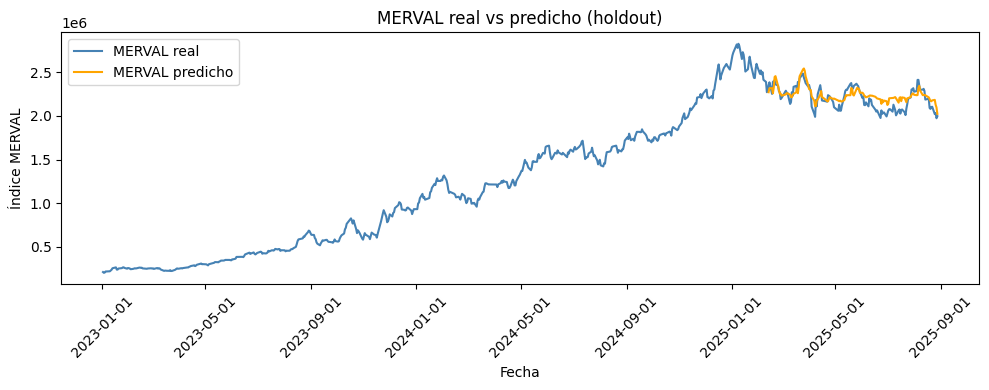

In [18]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


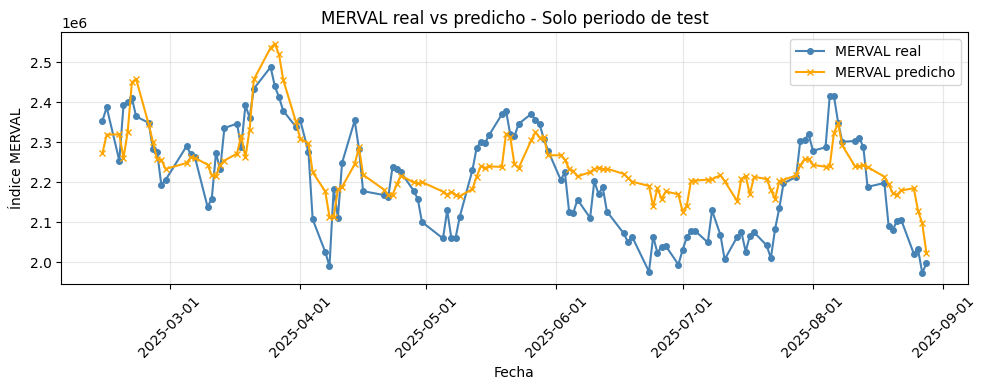

In [19]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

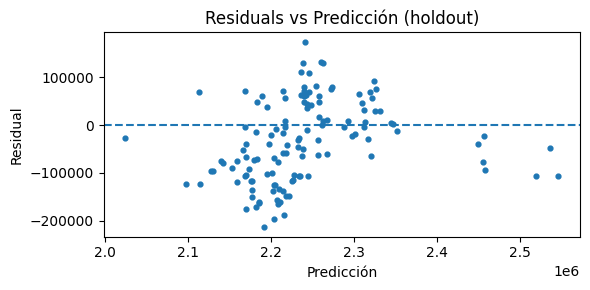

In [20]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


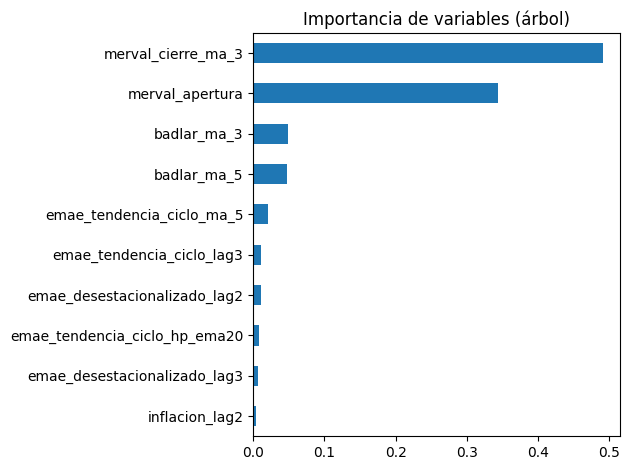

In [21]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()
